# 05 · Sky-vs-Structure Segmentation

**Goal:** segment each frame into "sky" and "structure" and compare segmenters as an ablation.

- **Classical sky mask** (FROM SCRATCH, `src/segmentation.py::classical_sky_mask`):
  brightness threshold + Canny edges + morphological closing. Flags anything that
  is *not* bright-smooth sky as structure (so trunk, branches **and** foliage).
- **LAB bark mask** (FROM SCRATCH, `src/segmentation.py::bark_color_mask_lab`):
  LAB-chrominance Mahalanobis distance to sampled bark colour + vertical spatial
  prior + gradient-density texture rescue. This is the segmenter the **production
  pipeline** (notebook 06 / `scripts/run_pipeline.py`) actually uses.
- **SAM** (library-wrapped, **optional**): Segment Anything with a trunk-base point
  prompt. The proposal scoped SAM as the learned alternative; it needs a downloaded
  checkpoint and is **skipped automatically** if the checkpoint is absent.

All segmenters share the convention `mask == True` → structure.

> **Empirical note (Week 3).** On these hazy-sky captures the bright-overcast
> assumption behind the classical brightness threshold does not hold — the sky
> rarely exceeds the 200-grey threshold — so both the classical and bark masks
> flag most of the frame as "structure". The comparison below is reported
> honestly; the consequence (the reprojection filter does little sky/structure
> separation and cloud cleanup falls to statistical outlier removal) is part of
> the report's discussion.

In [1]:
# Standard preamble — every notebook seeds np.random.seed(131).
import sys
from pathlib import Path

# Make `src/` importable from the notebooks/ directory.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
np.random.seed(131)

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from src import segmentation, viz
import cv2

TREE_ID = "tree_5"
FRAMES_DIR = PROJECT_ROOT / "data" / "frames" / TREE_ID

if not FRAMES_DIR.exists():
    raise FileNotFoundError(
        f"Frames directory not found at {FRAMES_DIR}.\n"
        "Run notebook 01 to extract frames for this tree."
    )

frame_paths = sorted(FRAMES_DIR.glob("frame_*.png"))
assert frame_paths, f"No frames in {FRAMES_DIR}"

# Auto-pick a representative frame: the one (over a strided scan) with the most
# sky, so the segmentation comparison figure shows the clearest sky/structure
# contrast available rather than a near-all-canopy frame.
scan = frame_paths[::8] or frame_paths
struct_frac = [
    (segmentation.classical_sky_mask(cv2.imread(str(p))).mean(), p) for p in scan
]
_, sample_path = min(struct_frac, key=lambda kv: kv[0])  # lowest structure = most sky
sample = cv2.imread(str(sample_path))
print(f"{len(frame_paths)} frames; using most-sky frame {sample_path.name}  shape={sample.shape}")

120 frames; using most-sky frame frame_00072.png  shape=(1920, 1080, 3)


## 1. Classical sky mask — from scratch

In [3]:
mask_classical = segmentation.classical_sky_mask(sample)
print(f"Classical: {mask_classical.mean()*100:.1f}% of pixels are structure")

Classical: 97.6% of pixels are structure


## 2. LAB bark mask — from scratch

This is the mask the production pipeline uses (notebook 06 / the CLI runner).
It targets woody structure specifically via LAB chrominance rather than brightness.

In [4]:
# bark_color_mask_lab returns a soft float mask in [0,1]; binarise at 0.5 so it
# matches the boolean (True=structure) convention used by the overlay + IoU helpers.
mask_bark = segmentation.bark_color_mask_lab(sample) > 0.5
print(f"LAB bark mask: {mask_bark.mean()*100:.1f}% of pixels are structure")

LAB bark mask: 100.0% of pixels are structure


## 3. SAM mask — library (optional)

The proposal's learned-segmentation alternative. Requires the ViT-B checkpoint
(see README). If it is not present this section is skipped and SAM is simply
omitted from the comparison below — the notebook still runs end to end.

In [5]:
mask_sam = None
sam = None
try:
    sam = segmentation.SamSegmenter()      # raises FileNotFoundError if no checkpoint
    mask_sam = sam(sample)
    print(f"SAM: {mask_sam.mean()*100:.1f}% of pixels are structure")
except Exception as e:
    print(f"SAM skipped ({type(e).__name__}): {e}")

SAM skipped (FileNotFoundError): SAM checkpoint not found at checkpoints/sam_vit_b_01ec64.pth. Download it (see README) then re-run.


## 4. Side-by-side comparison

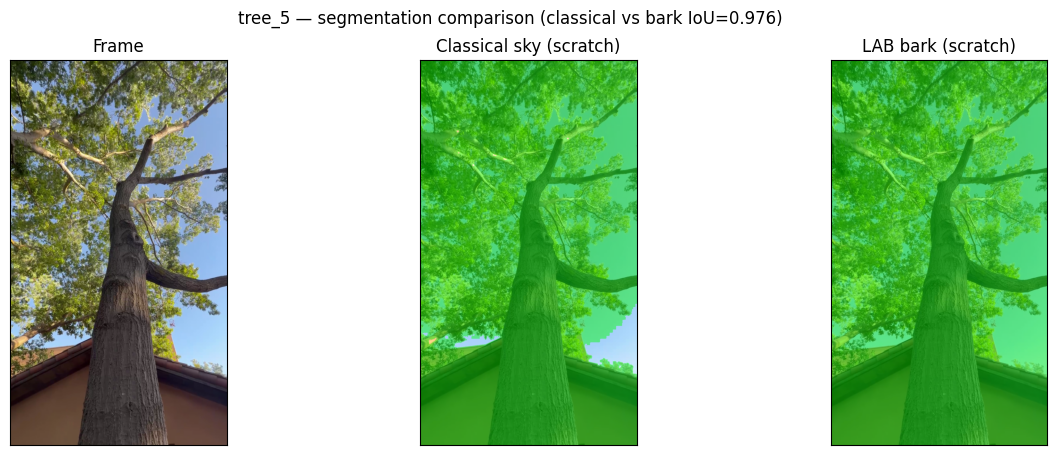

In [6]:
panels = [
    ("Frame", None),
    ("Classical sky (scratch)", mask_classical),
    ("LAB bark (scratch)", mask_bark),
]
if mask_sam is not None:
    panels.append(("SAM (library)", mask_sam))

fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
axes = np.atleast_1d(axes)
for ax, (title, m) in zip(axes, panels):
    if m is None:
        viz.show_image(sample, title=title, ax=ax)
    else:
        viz.plot_mask_overlay(sample, m, title=title, ax=ax)

iou_cb = segmentation.mask_iou(mask_classical, mask_bark)
fig.suptitle(f"{TREE_ID} — segmentation comparison (classical vs bark IoU={iou_cb:.3f})")
viz.save_fig(fig, f"05_{TREE_ID}_segmentation_comparison.png")
plt.show()

## 5. Batch-process frames (cache for inspection)

Notebook 06 recomputes its own per-frame bark masks from the CLAHE frames, so this
batch is only an on-disk cache for eyeballing. We stride the frames here to keep the
notebook fast; the full per-frame masking for the real run happens inside
`scripts/run_pipeline.py`.

In [7]:
MASKS_DIR = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_masks"
# Binarise the soft bark mask so all variants write the same boolean format.
bark_bin = lambda img: segmentation.bark_color_mask_lab(img) > 0.5
variants = [("classical", segmentation.classical_sky_mask), ("bark", bark_bin)]
if sam is not None:
    variants.append(("sam", sam))

batch_paths = frame_paths[::15]  # stride for speed; this is a cache, not the pipeline input
for variant_name, fn in variants:
    out = MASKS_DIR / variant_name
    out.mkdir(parents=True, exist_ok=True)
    for p in batch_paths:
        m = fn(cv2.imread(str(p)))
        segmentation.save_mask(m, out / (p.stem + ".png"))
    print(f"Wrote {len(batch_paths)} {variant_name} masks → {out}")

Wrote 8 classical masks → /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_masks/classical
Wrote 8 bark masks → /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_masks/bark
